In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,confusion_matrix,classification_report

In [24]:
df = pd.read_csv("data/bank.csv")

In [25]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [27]:
df.describe()


,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [28]:
df.describe(include= 'object')

,job,marital,education,default,housing,loan,contact,month,poutcome,deposit
count,11162,11162,11162,11162,11162,11162,11162,11162,11162,11162
unique,12,3,4,2,2,2,3,12,4,2
top,management,married,secondary,no,no,no,cellular,may,unknown,no
freq,2566,6351,5476,10994,5881,9702,8042,2824,8326,5873


In [29]:
X = df.drop(columns =['deposit'])       #features
y = df['deposit'] #target

In [30]:
df.shape


(11162, 17)

In [31]:
df.isnull().sum()[df.isnull().sum() > 0]


Series([], dtype: int64)

In [32]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

In [33]:
numeric_df = df.select_dtypes(include = [np.number])
for col in numeric_df:
    if df[col].dtype in ['int64', 'float64']:
        df[col]=df[col].fillna(df[col].median())


In [34]:
cat_df = df.select_dtypes(include='object')
for col in cat_df:
        if df[col].dtype in ['object', 'category']:
            df[col] = df[col].fillna(df[col].mode()[0])

In [35]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')

In [36]:
categorical_cols = ["job", "marital", "education", "default", "housing", "loan", "contact", "month", "poutcome"]
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print(df)

       age  balance  day  duration  campaign  pdays  previous deposit  \
0       59     2343    5      1042         1     -1         0     yes   
1       56       45    5      1467         1     -1         0     yes   
2       41     1270    5      1389         1     -1         0     yes   
3       55     2476    5       579         1     -1         0     yes   
4       54      184    5       673         2     -1         0     yes   
...    ...      ...  ...       ...       ...    ...       ...     ...   
11157   33        1   20       257         1     -1         0      no   
11158   39      733   16        83         4     -1         0      no   
11159   32       29   19       156         2     -1         0      no   
11160   43        0    8         9         2    172         5      no   
11161   34        0    9       628         1     -1         0      no   

       job_blue-collar  job_entrepreneur  ...  month_jul  month_jun  \
0                False             False  ...      F

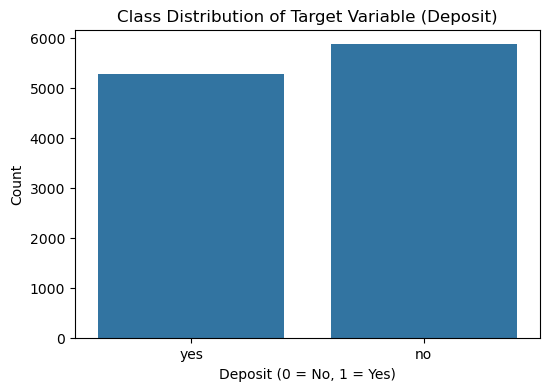

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x=y)
plt.title('Class Distribution of Target Variable (Deposit)')
plt.xlabel('Deposit (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()


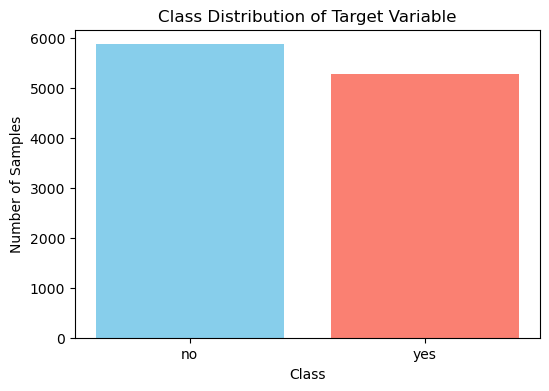

In [38]:
# Count of each class
class_counts = y.value_counts()

plt.figure(figsize=(6,4))
plt.bar(class_counts.index, class_counts.values, color=['skyblue', 'salmon'])
plt.xlabel('Class')
plt.ylabel('Number of Samples')
plt.title('Class Distribution of Target Variable')
plt.xticks(class_counts.index)
plt.show()


In [39]:
X = df.drop(columns =['deposit'])       
y = df['deposit'] 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model.fit(X_train, y_train)



c:\Users\Aqsa\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [40]:
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8145991939095387
Confusion Matrix:
 [[959 207]
 [207 860]]
Classification Report:
               precision    recall  f1-score   support

          no       0.82      0.82      0.82      1166
         yes       0.81      0.81      0.81      1067

    accuracy                           0.81      2233
   macro avg       0.81      0.81      0.81      2233
weighted avg       0.81      0.81      0.81      2233

